In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("exoplanet_data.csv", comment="#")


In [4]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.columns.tolist())

Shape: (583, 92)
Rows: 583
Columns: 92
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st

i dont understand 'su_kmagerr1', st_tefferr, 'pl_radj', 'pl_bmassjerr', and 'sy_gaiamagerr1'

Table label: Planet Name

column name: pl_name

description: name of the exoplanet

my words: planet's official name



Table label: Host Name

column name: hostname

description: name of the star the planet orbits

my words: the star that the planet goes around



table label: Discovery Method

column name: discoverymethod

description: method used to detect the planet

my words: how scientists found the planet



table label: Spectral Type

column name: st_spectype

description: classification of the star

my words: type of star (like size/temperature category)




table label: Equilibrium Temperature

column name: pl_eqt

description: estimated temperature of planet (K)

my words: how hot/cold the planet is



Table Label: Planet Mass

Column name: pl_bmassj

description: mass in Jupiter masses

my words: how heavy the planet is compared to Jupiter

In [5]:
small_df = df[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]

small_df = small_df.dropna()

print("Shape:", small_df.shape)
print("Rows:", small_df.shape[0])
print("Columns:", small_df.shape[1])

print(small_df.head())
print(small_df.tail())

print(small_df.columns.tolist())

Shape: (70, 6)
Rows: 70
Columns: 6
     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
562   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']


# 4.4 Analyze Data

In [6]:
counts = small_df["discoverymethod"].value_counts()
print(counts)

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


The most common discovery method is transit, the least common is imaging. 

Transit is the when the planet passes in front of a star. Radial velocity means the star escapes from planet gravity. Imaging is a direct picture of the planet. Microlensing means the gravity bends the light

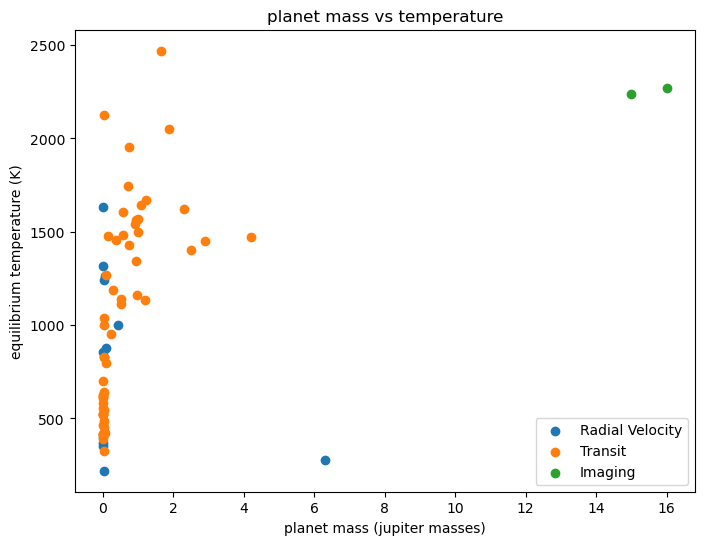

In [8]:
plt.figure(figsize=(8,6))

for method in small_df["discoverymethod"].unique():
    subset = small_df[small_df["discoverymethod"] == method]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label=method)

plt.xlabel("planet mass (jupiter masses)")
plt.ylabel("equilibrium temperature (K)")
plt.title("planet mass vs temperature")
plt.legend()
plt.show()

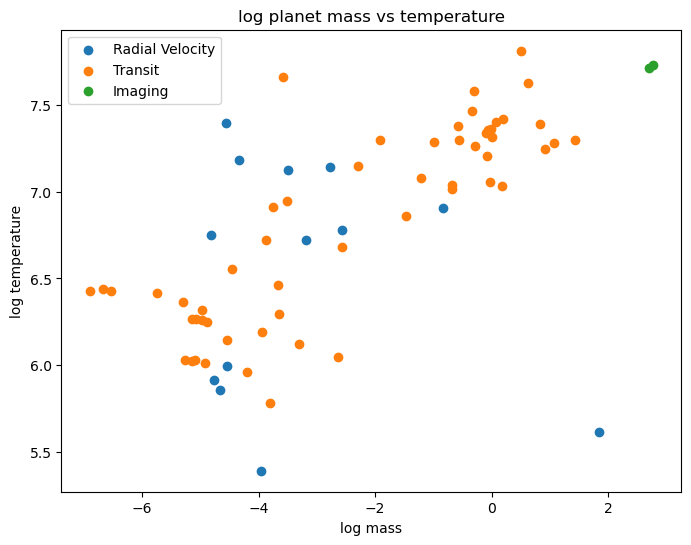

In [9]:
plt.figure(figsize=(8,6))

for method in small_df["discoverymethod"].unique():
    subset = small_df[small_df["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)

plt.xlabel("log mass")
plt.ylabel("log temperature")
plt.title("log planet mass vs temperature")
plt.legend()
plt.show()

Imaging planets are usually more massive

In [10]:
filtered = small_df[small_df["pl_bmassj"] > 5]

coldest = filtered.loc[filtered["pl_eqt"].idxmin()]

print(coldest)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


In [11]:
print("name:", coldest["pl_name"])
print("index:", coldest.name)
print("temp:", coldest["pl_eqt"])
print("mass:", coldest["pl_bmassj"])
print("star type:", coldest["st_spectype"])



name: eps Ind A b
index: 581
temp: 275.0
mass: 6.31
star type: K5 V


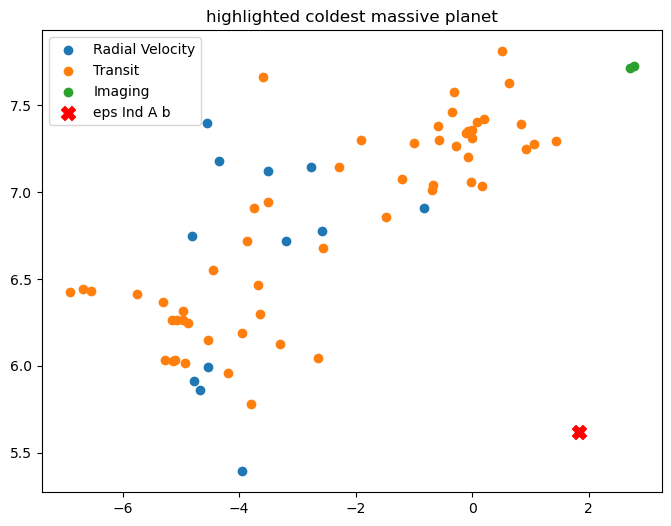

In [12]:
plt.figure(figsize=(8,6))

for method in small_df["discoverymethod"].unique():
    subset = small_df[small_df["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method)

# highlight
plt.scatter(np.log(coldest["pl_bmassj"]),
            np.log(coldest["pl_eqt"]),
            color="red", s=100, marker="X", label=coldest["pl_name"])

plt.legend()
plt.title("highlighted coldest massive planet")
plt.show()

# A temperate super-Jupiter imaged with JWST in the mid-infrared
Scientists used the James Webb Space Telescope to directly image a giant exoplanet orbiting a nearby star. The planet has a temperature of about 275 K (around 0°C), making it much colder than most previously imaged exoplanets, and its atmosphere may contain unusual chemical properties. This discovery is important because it shows that JWST can detect older, colder planets that were previously very difficult to observe.

Yes; the dataset identified a cold, massive planet that matches what's described in the paper (large gas giant with relatively low temperatures)

This is a special planet because it's one of the coldest exoplanets every directly imaged. It also had earth-like conditions, with a temperature of 275 K.

In the paper, the temperature is 275K and the mass is about 6 Jupiter masses. This matches my values very well! Small differences can be due to measurmeent uncertainty. 